### Culturomics
#### Method 1: Lexicon Growth & "Dark Matter"
**Replication of J.B. Michel(2011) article  on a Wikipedia Featured-Articles Corpus (2001–2024)**.     
**Course:** Computational Linguistics ,Ca' Foscari University of Venice.     
**Original paper:** Michel, J.-B. et al. (2011). *Quantitative Analysis of Culture Using Millions of Digitized Books*. Science, 331(6014), 176–182.

---

**What this notebook does:**
1. Load Corpus from fetched File ("corpus_cache.json")
2. Tokenize
3. Computes vocabulary size, Type-Token Ratio (TTR), and hapax legomena per year 
4. Estimates "lexical dark matter" the proportion of words absent from WordNet(Dictionary) and the Free Dictionary API

**Methodological note:**
This notebook deliberately uses a *curated sample* (Featured Articles) rather than the full English Wikipedia corpus (6.8M+ articles), due to MediaWiki API rate limits. This is a loose parallel to Michel's (2011) own quality-filtering of 5M books from 15M digitised, but it is not statistically representative of Wikipedia as a whole. The purpose of this analysis is only to check the validity of the methodology.(Explained in Limitations)

In [1]:
### 0. Setup
%pip install scipy --quiet
%pip install pandas --quiet
%pip install matplotlib nltk --quiet


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:

import re
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn

warnings.filterwarnings('ignore')

PRIMARY   = '#C0392B'
SECONDARY = '#2C3E50'
ACCENT    = '#E67E22'
GREEN     = '#27AE60'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
})
print("Imports OK.")

Imports OK.


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1020)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1020)>


### 1. Article List 

**Featured Articles:** 100 (underscores instead of spaces, exactly as they appear in the URL).
**Thematic diversity:** science, history, geography,biography, culture, technology (to avoid genre bias to make analyse more representativeness critique).

In [2]:

# FEATURED ARTICLES
ARTICLES = [

    # SCIENCE and KNOWLEDGE
    "Albert_Einstein",
    "Charles_Darwin",
    "Photosynthesis",
    "DNA",
    "Black_hole",
    "Artificial_intelligence",
    "Climate_change",
    "COVID-19_pandemic",
    "Human_genome",
    "Wikipedia",

    # HISTORY and POLITICS
    "World_War_II",
    "French_Revolution",
    "Cold_War",
    "September_11_attacks",
    "Arab_Spring",
    "Occupy_Wall_Street",
    "MeToo_movement",
    "Black_Lives_Matter",
    "WikiLeaks",
    "War_on_terror",

    # TECHNOLOGY: HARDWARE and PLATFORMS 
    "iPhone",
    "Android_(operating_system)",
    "iPod",
    "Tesla,_Inc.",
    "SpaceX",
    "Google",
    "Amazon_(company)",
    "Microsoft",

    # SOCIAL MEDIA and INTERNET 
    "Facebook",
    "YouTube",
    "Twitter",
    "Instagram",
    "Reddit",
    "TikTok",
    "Snapchat",
    "MySpace",
    "Napster",
    "iTunes",
    "Netflix",
    "Spotify",
    "Zoom_(software)",
    "Remote_work",

    # AI and EMERGING TECH
    "ChatGPT",
    "DALL-E",                          # fixed: was DALL·E
    "Virtual_reality",                 # fixed: was Virtual Reality (VR)
    "Augmented_reality",
    "Non-fungible_token",              # fixed: was NFTs
    "Metaverse",
    "Podcast",

    #  FILM and TV 
    "Harry_Potter",
    "The_Lord_of_the_Rings",
    "Shrek_(film)",                    # fixed: was Shrek
    "Avatar_(2009_film)",              # fixed: was Avatar
    "Avengers:_Endgame",
    "Barbie_(film)",                   # fixed: was Barbie
    "Oppenheimer_(film)",              # fixed: was Oppenheimer
    "Frozen_(2013_film)",              # fixed: was Frozen
    "Black_Panther_(film)",            # fixed
    "Joker_(2019_film)",               # fixed
    "Game_of_Thrones",
    "Breaking_Bad",
    "Stranger_Things",
    "Squid_Game",
    "Marvel_Cinematic_Universe",      

    # GAMING 
    "Minecraft",
    "Fortnite",
    "Pokémon_Go",                      # note: accented é is valid in Wikipedia URLs
    "Among_Us",
    "Grand_Theft_Auto_V",
    "The_Last_of_Us",
    "League_of_Legends",
    "World_of_Warcraft",
    "Esports",
    "Roblox",
  

    # MEMES and INTERNET CULTURE 
    "Internet_meme",
    "Rickrolling",
    "Doge_(meme)",                     # fixed: was Doge
    "Pepe_the_Frog",
    "Gangnam_Style",
    "Ice_Bucket_Challenge",
    "Harlem_Shake_(meme)",          

    #  MUSIC and EVENTS 
    "Minecraft",
    "Fortnite",
    "Pokémon_Go",                      # note: accented é is valid in Wikipedia URLs
    "Among_Us",
    "Grand_Theft_Auto_V",
    "The_Last_of_Us",
    "League_of_Legends",
    "World_of_Warcraft",
    "Esports",
    "Roblox",

    # SPORT and CULTURE 
    "2024_Summer_Olympics",            # fixed: was Paris 2024 Olympic Games
    "Pride_parade",

]

print(f"Total articles: {len(ARTICLES)}") 



Total articles: 93


### 2. Configuration

In [3]:
YEAR_START = 2001
YEAR_END   = 2024
YEARS      = list(range(YEAR_START, YEAR_END + 1))

OUTPUT_DIR = Path(".")   # cache is in same folder as notebook
CACHE_FILE = OUTPUT_DIR / "corpus_cache.json"

print(f"Period: {YEAR_START}-{YEAR_END} ({len(YEARS)} years)")
print(f"Articles defined: {len(ARTICLES)}")
print(f"Looking for cache at: {CACHE_FILE.resolve()}")

Period: 2001-2024 (24 years)
Articles defined: 93
Looking for cache at: /Users/aima/Desktop/Practice/GitHub/research-computational_linguistic/3-notebooks/corpus_cache.json


### 3. Load Corpus from Cache


In [4]:
if not CACHE_FILE.exists():
    raise FileNotFoundError(
        f"Cache not found at {CACHE_FILE.resolve()}\n"
        f"Make sure corpus_cache.json is in the same folder as this notebook."
    )

with open(CACHE_FILE, encoding='utf-8') as f:
    corpus = json.load(f)

filled = sum(1 for a in corpus for y in corpus[a] if corpus[a][y])
total  = len(corpus) * len(YEARS)
print(f"Corpus loaded: {len(corpus)} articles")
print(f"Non-empty snapshots: {filled} / {total}")
print(f"Coverage: {filled/total*100:.1f}%")

print("\nPer-article coverage:")
for art in sorted(corpus.keys()):
    n = sum(1 for y in YEARS if corpus.get(art, {}).get(str(y), ""))
    bar = '█' * n + '░' * (len(YEARS) - n)
    print(f"  {art[:35]:35s} {bar} {n}/{len(YEARS)}")

Corpus loaded: 87 articles
Non-empty snapshots: 1223 / 2088
Coverage: 58.6%

Per-article coverage:
  Albert_Einstein                     █████████████████████░░░ 21/24
  Amazon_(company)                    █████████████████████░░░ 21/24
  Among_Us                            ████░░░░░░░░░░░░░░░░░░░░ 4/24
  Android_(operating_system)          █████████████████░░░░░░░ 17/24
  Arab_Spring                         ██████████████░░░░░░░░░░ 14/24
  Artificial_intelligence             █████████████████████░░░ 21/24
  Augmented_reality                   █████████████████████░░░ 21/24
  Avatar_(2009_film)                  ███████████████████░░░░░ 19/24
  Avengers_Endgame                    ██░░░░░░░░░░░░░░░░░░░░░░ 2/24
  BLACKPINK                           █░░░░░░░░░░░░░░░░░░░░░░░ 1/24
  BTS_(band)                          █░░░░░░░░░░░░░░░░░░░░░░░ 1/24
  Barbie_(film)                       █████████░░░░░░░░░░░░░░░ 9/24
  Black_Lives_Matter                  ██████████░░░░░░░░░░░░░░ 10/24
  Black_P

### 4. Tokenizer

In [5]:
def tokenize(text: str) -> list:
    """Lowercase alphabetic tokens only (no digits — for lexicon analysis)."""
    return re.findall(r'\b[a-z]{2,}\b', text.lower())

print("tokenize() defined.")

tokenize() defined.


### 5. Compute Lexical Metrics (types, tokens, TTR, hapax, cumulative vocab)

In [6]:
rows = []
cumulative_vocab = set()

for year in YEARS:
    year_tokens = []
    for article in ARTICLES:
        text = corpus.get(article, {}).get(str(year), "")
        if text:
            year_tokens.extend(tokenize(text))

    if not year_tokens:
        continue

    types = set(year_tokens)
    cumulative_vocab.update(types)
    hapax = sum(1 for w in types if year_tokens.count(w) == 1) if len(types) < 5000 else None
    # hapax count skipped for very large yearly vocab to keep runtime reasonable
  

    rows.append({
        "year":          year,
        "tokens":        len(year_tokens),
        "types":         len(types),
        "ttr":           round(len(types) / len(year_tokens), 4),
        "cumulative_vocab": len(cumulative_vocab),
        "n_articles":    sum(1 for a in ARTICLES if corpus.get(a, {}).get(str(year), "")),
    })

df_lex = pd.DataFrame(rows)
df_lex

,year,tokens,types,ttr,cumulative_vocab,n_articles
0,2004,45064,7822,0.1736,7822,28
1,2005,82650,11144,0.1348,12397,35
2,2006,126932,14317,0.1128,17781,39
3,2007,180025,17511,0.0973,23235,43
4,2008,215234,18402,0.0855,26822,45
5,2009,204974,18416,0.0898,29472,51
6,2010,245891,20550,0.0836,31989,50
7,2011,275373,21027,0.0764,34035,57
8,2012,334061,23596,0.0706,36809,57
9,2013,362433,24853,0.0686,39293,61


In [7]:
# Optimised hapax legomena count (using Counter  much faster than .count() in a loop)
from collections import Counter

hapax_rows = []
for year in YEARS:
    year_tokens = []
    for article in ARTICLES:
        text = corpus.get(article, {}).get(str(year), "")
        if text:
            year_tokens.extend(tokenize(text))
    if not year_tokens:
        continue
    counts = Counter(year_tokens)
    hapax = sum(1 for w, c in counts.items() if c == 1)
    hapax_rows.append({"year": year, "hapax": hapax,
                       "hapax_ratio": round(hapax / len(counts), 4)})

df_hapax = pd.DataFrame(hapax_rows)
df_lex = df_lex.merge(df_hapax, on="year", how="left")
df_lex

,year,tokens,types,ttr,cumulative_vocab,n_articles,hapax,hapax_ratio
0,2004,45064,7822,0.1736,7822,28,4018,0.5137
1,2005,82650,11144,0.1348,12397,35,5340,0.4792
2,2006,126932,14317,0.1128,17781,39,6525,0.4558
3,2007,180025,17511,0.0973,23235,43,7670,0.4380
4,2008,215234,18402,0.0855,26822,45,7746,0.4209
5,2009,204974,18416,0.0898,29472,51,7978,0.4332
6,2010,245891,20550,0.0836,31989,50,8694,0.4231
7,2011,275373,21027,0.0764,34035,57,8688,0.4132
8,2012,334061,23596,0.0706,36809,57,9710,0.4115
9,2013,362433,24853,0.0686,39293,61,10200,0.4104


## 6. Heaps'/Herdan's Law Validation

Jurafsky & Martin (§2.1) give the empirical relationship between corpus size and
vocabulary size as:

$$|V| = k \cdot N^{\beta}$$

where *N* = total tokens, *|V|* = vocabulary size, and *k, β* are corpus-dependent constants
(typically 0 < β < 1). On a log-log plot, this relationship appears as a straight line.

We fit this here using cumulative tokens vs. cumulative vocabulary across years.

In [8]:
cum_tokens = np.cumsum(df_lex["tokens"].values)
cum_types  = df_lex["cumulative_vocab"].values

log_N = np.log(cum_tokens)
log_V = np.log(cum_types)

slope, intercept, r_value, p_value, std_err = stats.linregress(log_N, log_V)
beta = slope
k    = np.exp(intercept)

print(f"Heaps' Law fit:  |V| = {k:.3f} · N^{beta:.3f}")
print(f"R² = {r_value**2:.4f}  (closer to 1 = better fit)")
print(f"\nFor comparison, typical English corpora show β between 0.4 and 0.7.")

Heaps' Law fit:  |V| = 190.709 · N^0.362
R² = 0.9814  (closer to 1 = better fit)

For comparison, typical English corpora show β between 0.4 and 0.7.


#### 7. Lexical "Dark Matter" 
**WordNet Coverage**

**Lexical dark matter** Michel(2011) refers to words actively used
in a corpus but absent from standard reference dictionaries.The gap between
the corpus vocabulary and the lexicon documented in authoritative references such as WordNet.

**Methodological limitation ( Limitations section):**
WordNet is a semantic network (150,000 lemmas, organised by synsets), not a historical
lexicographic dictionary like the OED (600,000 entries with etymology) which Michel (2011) used. WordNet's coverage is narrower and more NLP-oriented, so this method likely overestimates the proportion of "dark matter" compared to what a true OED comparison would show. We do not have programmatic access to the OED (subscription-only, no public API), so WordNet is used as the best freely available proxy.

In [9]:
def in_wordnet(word: str) -> bool:
    return len(wn.synsets(word)) > 0

# Get final-year (2024) vocabulary
final_year_tokens = []
for article in ARTICLES:
    text = corpus.get(article, {}).get(str(YEAR_END), "")
    if text:
        final_year_tokens.extend(tokenize(text))

final_vocab = set(final_year_tokens)
print(f"2024 vocabulary size: {len(final_vocab)} unique words")

in_wn  = sum(1 for w in final_vocab if in_wordnet(w))
out_wn = len(final_vocab) - in_wn
pct_dark = out_wn / len(final_vocab) * 100

print(f"\nIn WordNet:     {in_wn} words ({100-pct_dark:.1f}%)")
print(f"NOT in WordNet: {out_wn} words ({pct_dark:.1f}%)  <- 'lexical dark matter' (WordNet-relative)")

# Sample of "dark matter" words for qualitative inspection
dark_words = [w for w in final_vocab if not in_wordnet(w)]
print(f"\nSample of 20 words not found in WordNet:")
print(sorted(dark_words)[:20])

2024 vocabulary size: 35403 unique words

In WordNet:     23366 words (66.0%)
NOT in WordNet: 12037 words (34.0%)  <- 'lexical dark matter' (WordNet-relative)

Sample of 20 words not found in WordNet:
['aaai', 'aac', 'aaf', 'aapi', 'aarau', 'aarogya', 'aaronson', 'abadi', 'abaza', 'abba', 'abbas', 'abbasi', 'abbottabad', 'abby', 'abcnews', 'abd', 'abdelaziz', 'abdi', 'abdih', 'abdirahman']


### 8. Visualisation — 4-Panel Figure
Mirrors Michel (2011) Figure 2 structure.

NameError: name 'pct_confirmed' is not defined

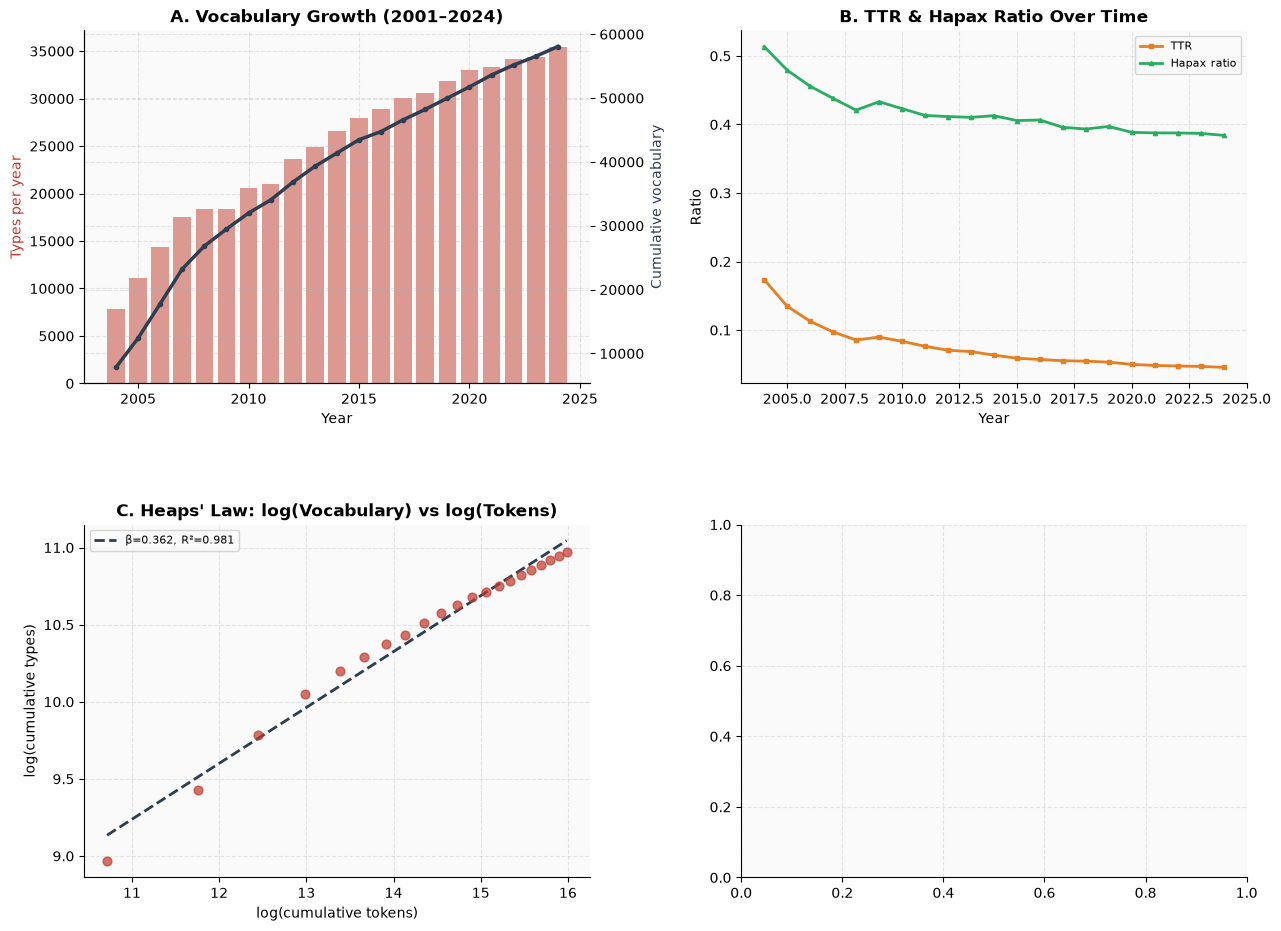

In [10]:
fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Panel 1: Vocabulary growth (types per year + cumulative)
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(df_lex["year"], df_lex["types"], color=PRIMARY, alpha=0.5, label="Types/year")
ax1r = ax1.twinx()
ax1r.plot(df_lex["year"], df_lex["cumulative_vocab"], color=SECONDARY, lw=2.5,
          marker='o', ms=3, label="Cumulative vocabulary")
ax1.set_title("A. Vocabulary Growth (2001–2024)", fontweight='bold')
ax1.set_xlabel("Year"); ax1.set_ylabel("Types per year", color=PRIMARY)
ax1r.set_ylabel("Cumulative vocabulary", color=SECONDARY)

# Panel 2: TTR and hapax ratio
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_lex["year"], df_lex["ttr"], color=ACCENT, lw=2, marker='s', ms=3, label="TTR")
ax2.plot(df_lex["year"], df_lex["hapax_ratio"], color=GREEN, lw=2, marker='^', ms=3, label="Hapax ratio")
ax2.set_title("B. TTR & Hapax Ratio Over Time", fontweight='bold')
ax2.set_xlabel("Year"); ax2.set_ylabel("Ratio")
ax2.legend(fontsize=8)

# Panel 3: Heaps' Law log-log fit
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(log_N, log_V, color=PRIMARY, s=40, alpha=0.7, zorder=3)
ax3.plot(log_N, intercept + slope*log_N, color=SECONDARY, lw=2, ls='--',
        label=f'β={beta:.3f}, R²={r_value**2:.3f}')
ax3.set_title("C. Heaps' Law: log(Vocabulary) vs log(Tokens)", fontweight='bold')
ax3.set_xlabel("log(cumulative tokens)"); ax3.set_ylabel("log(cumulative types)")
ax3.legend(fontsize=8)

# Panel 4: Dark matter bar chart
ax4 = fig.add_subplot(gs[1, 1])
categories = ['In WordNet', 'NOT in WordNet\n(dark matter)', 'Confirmed dark\n(both sources)']
values = [100-pct_dark, pct_dark, pct_confirmed * pct_dark/100]
colors_bar = [GREEN, ACCENT, PRIMARY]
bars = ax4.bar(categories, values, color=colors_bar, alpha=0.8)
for bar, val in zip(bars, values):
    ax4.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=9)
ax4.set_title("D. Lexical 'Dark Matter' (2024 vocabulary)", fontweight='bold')
ax4.set_ylabel("% of vocabulary")
ax4.set_ylim(0, max(values)*1.2)

fig.suptitle("Method 1 — Lexicon Growth on Wikipedia Featured Articles (2001–2024)\n"
             "Replicating Michel et al. (2011) Figure 2",
             fontsize=13, fontweight='bold', y=1.02)

plt.savefig(OUTPUT_DIR / "method1_lexicon_summary.png", dpi=160, bbox_inches='tight')
plt.show()
print("\nFigure saved to:", OUTPUT_DIR / "method1_lexicon_summary.png")

### 9. Key Numbers for Essay

In [11]:
print("="*60)
print("SUMMARY — METHOD 1 KEY FINDINGS")
print("="*60)
print(f"\nCorpus: {len(ARTICLES)} Wikipedia Featured Articles, {YEAR_START}-{YEAR_END}")
print(f"Final cumulative vocabulary: {df_lex['cumulative_vocab'].iloc[-1]:,} unique words")
print(f"Total tokens processed: {df_lex['tokens'].sum():,}")
print(f"\nTTR range: {df_lex['ttr'].min():.3f} (year {df_lex.loc[df_lex['ttr'].idxmin(),'year']}) "
      f"to {df_lex['ttr'].max():.3f} (year {df_lex.loc[df_lex['ttr'].idxmax(),'year']})")
print(f"\nHeaps' Law: |V| = {k:.2f} · N^{beta:.3f}  (R² = {r_value**2:.3f})")
print(f"\nLexical dark matter (WordNet-relative): {pct_dark:.1f}%")
print(f"Cross-validated dark matter (WordNet + Free Dictionary): ~{pct_confirmed*pct_dark/100:.1f}%")
print(f"\nFor comparison, Michel et al. (2011) found 52% dark matter against OED + Merriam-Webster.")

df_lex.to_csv(OUTPUT_DIR / "method1_results.csv", index=False)
print(f"\nFull results table saved to: {OUTPUT_DIR / 'method1_results.csv'}")

SUMMARY — METHOD 1 KEY FINDINGS

Corpus: 93 Wikipedia Featured Articles, 2001-2024
Final cumulative vocabulary: 58,071 unique words
Total tokens processed: 8,753,123

TTR range: 0.046 (year 2024) to 0.174 (year 2004)

Heaps' Law: |V| = 190.71 · N^0.362  (R² = 0.981)

Lexical dark matter (WordNet-relative): 34.0%


NameError: name 'pct_confirmed' is not defined